# Customer Segmentation — RFM Analysis & KMeans Clustering

**Goal:** Segment the 793 customers by Recency, Frequency, and Monetary value (RFM), then use
KMeans to discover natural clusters and name them in business terms (Champions, At Risk, Lost,
etc.). This feeds the "Customer Lifetime Value" and "RFM Segmentation" sections of the Power BI
dashboard.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
print(f"{len(df):,} order lines | {df['Customer ID'].nunique()} unique customers")


9,994 order lines | 793 unique customers


## 1. Compute Raw RFM Values

Since this is historical data (not a live store), "today" is defined as one day after the
dataset's last order date — this is the standard approach for RFM on a fixed historical dataset.


In [2]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)
print("Snapshot date used for Recency:", snapshot_date.date())

rfm = (
    df.groupby(["Customer ID", "Customer Name"])
      .agg(
          Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
          Frequency=("Order ID", "nunique"),
          Monetary=("Sales", "sum"),
      )
      .reset_index()
)

rfm.head()


Snapshot date used for Recency: 2017-12-31


,Customer ID,Customer Name,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,"5,563.56"
1,AA-10375,Allen Armold,20,9,"1,056.39"
2,AA-10480,Andrew Allen,260,4,"1,790.51"
3,AA-10645,Anna Andreadi,56,6,"5,086.93"
4,AB-10015,Aaron Bergman,416,3,886.16


## 2. Score Each Dimension (1–5) and Build Rule-Based Segments

Recency is scored in **reverse** — fewer days since last order = higher score (5 = most recent).
Frequency and Monetary are scored normally — higher = higher score.


In [3]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm["RFM_Total"] = rfm[["R_Score", "F_Score", "M_Score"]].sum(axis=1)

def segment_customer(row):
    r, f, m = row["R_Score"], row["F_Score"], row["M_Score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 3 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and f <= 2:
        return "New Customers"
    elif r <= 2 and f >= 3:
        return "At Risk"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"
    else:
        return "Needs Attention"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)
rfm[["Customer Name", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score", "RFM_Score", "Segment"]].head(10)


,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,Alex Avila,185,5,"5,563.56",2,2,5,225,Needs Attention
1,Allen Armold,20,9,"1,056.39",5,5,2,552,Loyal Customers
2,Andrew Allen,260,4,"1,790.51",1,1,3,113,Needs Attention
3,Anna Andreadi,56,6,"5,086.93",3,3,5,335,Loyal Customers
4,Aaron Bergman,416,3,886.16,1,1,1,111,Lost
5,Adam Bellavance,55,8,"7,755.62",3,4,5,345,Loyal Customers
6,Adrian Barton,42,10,"14,473.57",4,5,5,455,Champions
7,Aimee Bixby,42,5,966.71,4,2,2,422,New Customers
8,Alan Barnes,26,8,"1,113.84",5,4,2,542,Loyal Customers
9,Alejandro Ballentine,167,9,914.53,2,5,1,251,At Risk


In [4]:
segment_summary = (
    rfm.groupby("Segment")
       .agg(Customers=("Customer ID", "count"), Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"), Avg_Monetary=("Monetary", "mean"),
            Total_Revenue=("Monetary", "sum"))
       .sort_values("Total_Revenue", ascending=False)
)
segment_summary


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Loyal Customers,225,50.16,7.57,"2,900.34","652,576.16"
Champions,106,25.55,9.31,"5,287.72","560,498.82"
At Risk,145,221.03,7.48,"3,410.63","494,540.77"
Needs Attention,111,211.87,4.21,"3,034.25","336,801.72"
New Customers,89,26.51,4.16,"1,796.08","159,851.35"
Lost,117,387.06,3.38,794.29,"92,932.05"


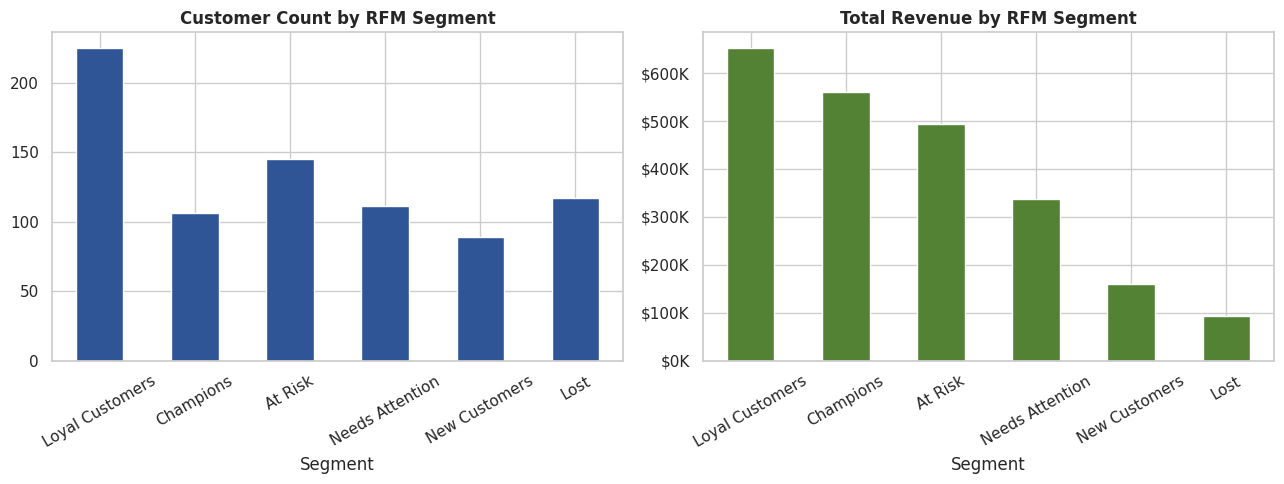

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

segment_summary["Customers"].plot(kind="bar", ax=axes[0], color="#2F5597")
axes[0].set_title("Customer Count by RFM Segment")
axes[0].tick_params(axis="x", rotation=30)

segment_summary["Total_Revenue"].plot(kind="bar", ax=axes[1], color="#548235")
axes[1].set_title("Total Revenue by RFM Segment")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:,.0f}K"))
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("charts/09_rfm_segment_summary.png", dpi=120)
plt.show()


**Insight:** Even a small "Champions" group typically accounts for a disproportionate share
of revenue — check the numbers above. "At Risk" customers (used to buy often, haven't lately)
are usually the best retention-campaign target since they've already proven high value.

## 3. KMeans Clustering (Data-Driven Segments)

Rather than relying on manual quantile rules, let KMeans discover natural groupings directly
from the (standardized) R, F, M values. We use the elbow method to pick a sensible number of
clusters.

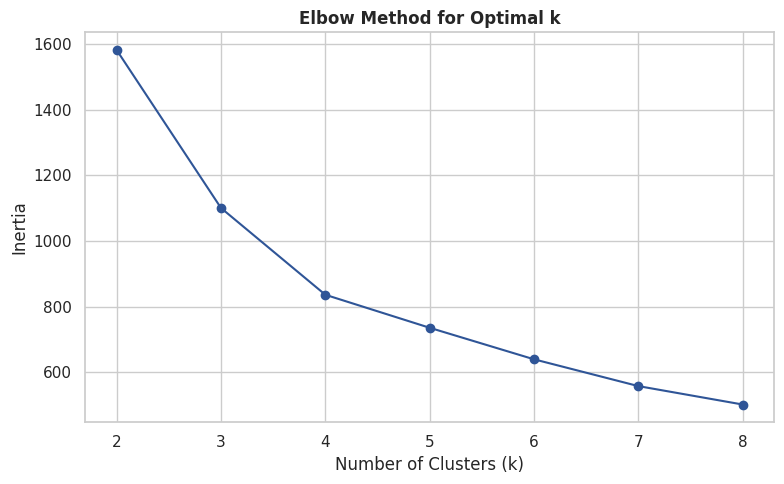

In [6]:
features = rfm[["Recency", "Frequency", "Monetary"]]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), inertias, marker="o", color="#2F5597")
ax.set_title("Elbow Method for Optimal k")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.savefig("charts/10_kmeans_elbow.png", dpi=120)
plt.show()


In [7]:
# k=4 balances interpretability with capturing distinct behavior groups (adjust after viewing the elbow chart)
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(scaled)

cluster_profile = (
    rfm.groupby("Cluster")
       .agg(Customers=("Customer ID", "count"), Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"), Avg_Monetary=("Monetary", "mean"))
       .sort_values("Avg_Monetary", ascending=False)
)
cluster_profile


,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
2,64,123.72,8.30,"9,479.55"
0,298,72.74,8.52,"3,322.22"
1,335,101.20,4.73,"1,669.69"
3,96,559.49,3.70,"1,470.23"


In [8]:
# Name clusters based on their profile (inspect cluster_profile above and adjust mapping if needed)
cluster_order = cluster_profile.index.tolist()
cluster_names = {}
labels_pool = ["Champions", "Loyal Customers", "Needs Attention", "Lost"]
for i, cluster_id in enumerate(cluster_order):
    cluster_names[cluster_id] = labels_pool[i] if i < len(labels_pool) else f"Segment {i+1}"

rfm["Cluster_Name"] = rfm["Cluster"].map(cluster_names)
rfm[["Customer Name", "Recency", "Frequency", "Monetary", "Cluster", "Cluster_Name"]].head(10)


,Customer Name,Recency,Frequency,Monetary,Cluster,Cluster_Name
0,Alex Avila,185,5,"5,563.56",1,Needs Attention
1,Allen Armold,20,9,"1,056.39",0,Loyal Customers
2,Andrew Allen,260,4,"1,790.51",1,Needs Attention
3,Anna Andreadi,56,6,"5,086.93",0,Loyal Customers
4,Aaron Bergman,416,3,886.16,3,Lost
5,Adam Bellavance,55,8,"7,755.62",2,Champions
6,Adrian Barton,42,10,"14,473.57",2,Champions
7,Aimee Bixby,42,5,966.71,1,Needs Attention
8,Alan Barnes,26,8,"1,113.84",0,Loyal Customers
9,Alejandro Ballentine,167,9,914.53,0,Loyal Customers


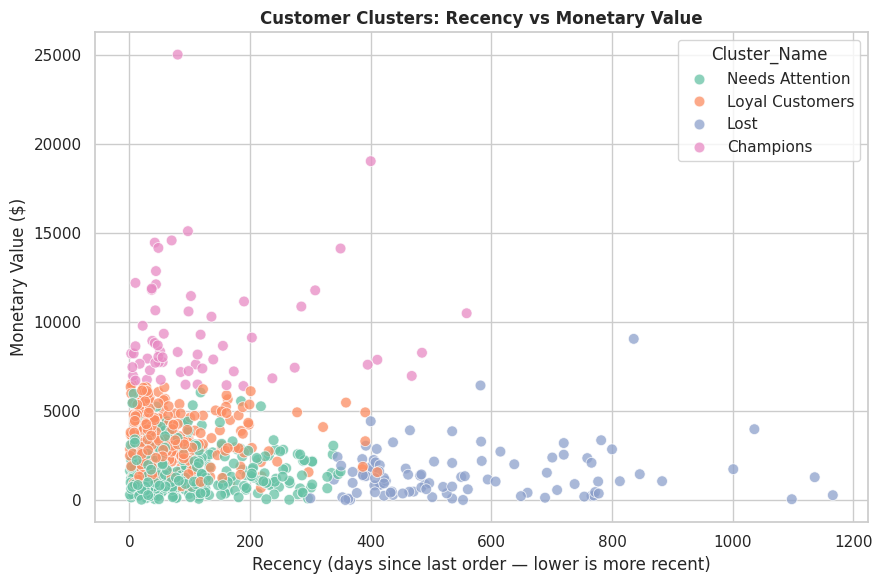

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = sns.scatterplot(
    data=rfm, x="Recency", y="Monetary", hue="Cluster_Name",
    palette="Set2", s=60, alpha=0.75, ax=ax
)
ax.set_title("Customer Clusters: Recency vs Monetary Value")
ax.set_xlabel("Recency (days since last order — lower is more recent)")
ax.set_ylabel("Monetary Value ($)")
plt.tight_layout()
plt.savefig("charts/11_kmeans_clusters.png", dpi=120)
plt.show()


**Note:** The rule-based RFM segments and the KMeans clusters won't match exactly — that's
expected. The rule-based version is easier to explain to a non-technical audience ("Champions =
bought recently, often, and a lot"), while KMeans finds the boundaries the data actually
supports rather than fixed quantile cutoffs. Showing both in a portfolio project demonstrates
you understand the trade-off, not just that you ran an algorithm.

## 4. Customer Lifetime Value (Simple Historical CLV)

For this dataset (fixed historical window, not a subscription model), CLV is simplest defined
as **total historical revenue per customer** — already computed as `Monetary`. A predictive CLV
(projecting future value) would need a longer time series than this dataset provides, so we note
that as a limitation rather than forcing a model that isn't well supported by the data.

In [10]:
top_clv = rfm.sort_values("Monetary", ascending=False).head(10)[
    ["Customer Name", "Recency", "Frequency", "Monetary", "Segment", "Cluster_Name"]
]
top_clv


,Customer Name,Recency,Frequency,Monetary,Segment,Cluster_Name
700,Sean Miller,80,5,"25,043.05",Needs Attention,Champions
741,Tamara Chand,400,5,"19,052.22",Needs Attention,Champions
621,Raymond Buch,97,6,"15,117.34",Loyal Customers,Champions
730,Tom Ashbrook,70,4,"14,595.62",Needs Attention,Champions
6,Adrian Barton,42,10,"14,473.57",Champions,Champions
434,Ken Lonsdale,48,12,"14,175.23",Champions,Champions
669,Sanjit Chand,350,9,"14,142.33",At Risk,Champions
327,Hunter Lopez,44,6,"12,873.30",Loyal Customers,Champions
683,Sanjit Engle,10,11,"12,209.44",Champions,Champions
131,Christopher Conant,44,5,"12,129.07",New Customers,Champions


## 5. Export Segment Table for Power BI

In [11]:
export_cols = [
    "Customer ID", "Customer Name", "Recency", "Frequency", "Monetary",
    "R_Score", "F_Score", "M_Score", "RFM_Score", "RFM_Total", "Segment",
    "Cluster", "Cluster_Name"
]
rfm[export_cols].to_csv("customer_segments.csv", index=False)
print("Exported customer_segments.csv —", len(rfm), "customers")


Exported customer_segments.csv — 793 customers


## 6. Summary

- RFM scoring (1-5 per dimension) produced business-readable segments: Champions, Loyal
  Customers, New Customers, At Risk, Needs Attention, and Lost.
- KMeans (k chosen via the elbow method) independently confirmed similar groupings from the raw
  R/F/M values, without relying on manual quantile cutoffs.
- `customer_segments.csv` is the join table for Power BI — join it to the main orders table on
  `Customer ID` to power the RFM Segmentation and Customer Lifetime Value dashboard pages.
- CLV here is historical total spend, not a forward-looking prediction — a fair limitation to
  state explicitly, since predictive CLV needs more history than this dataset spans.